Note: One image 561x3030 is taking too much memory to process; we will have to either split into 3 or compress them.

In [ ]:
# Imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from tqdm.autonotebook import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import math

<ipython-input-1-9e6c1f4d12ad>:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
# for temporary use, while we finish data processing
!pip install datasets
from datasets import load_dataset

ds = load_dataset("stochastic/random_streetview_images_pano_v0.0.2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.85k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

(…)-00000-of-00006-9089804f14aaccce.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

(…)-00002-of-00006-f8ce946916e330c8.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

(…)-00003-of-00006-f8e97309feb01a88.parquet:   0%|          | 0.00/466M [00:00<?, ?B/s]

(…)-00004-of-00006-450fd3815b925113.parquet:   0%|          | 0.00/467M [00:00<?, ?B/s]

(…)-00005-of-00006-a0dd1c677754786b.parquet:   0%|          | 0.00/465M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11054 [00:00<?, ? examples/s]

In [ ]:
# convert the lat and long to float
ds = ds.map(lambda x: {'latitude': float(x['latitude']), 'longitude': float(x['longitude'])})

Map:   0%|          | 0/11054 [00:00<?, ? examples/s]

In [ ]:
#@title Create a loss function for Haversine Distance
class HaversineLoss(torch.nn.Module):
    def __init__(self):
        super(HaversineLoss, self).__init__()
        # Earth's radius in km (use 3956 for miles)
        self.R = torch.tensor(6371.0, requires_grad=False)

    def forward(self, preds, targets):
        # Ensure R is on the same device as inputs
        self.R = self.R.to(preds.device)

        # Convert degrees to radians
        preds_rad = torch.deg2rad(preds)
        targets_rad = torch.deg2rad(targets)

        # Split into latitude and longitude
        pred_lat, pred_lon = preds_rad[:, 0], preds_rad[:, 1]
        target_lat, target_lon = targets_rad[:, 0], targets_rad[:, 1]

        # Calculate differences
        dlat = target_lat - pred_lat
        dlon = target_lon - pred_lon

        # Haversine formula
        a = (torch.sin(dlat/2)**2 +
             torch.cos(pred_lat) * torch.cos(target_lat) * torch.sin(dlon/2)**2)
        c = 2 * torch.asin(torch.sqrt(a))

        # Calculate distance
        distances = c * self.R

        # Return mean distance as loss
        return torch.mean(distances)

## Training from Scratch - Testing with a simple network

In [ ]:
# convert to pytorch
imgs = ds.with_format("torch")['train']
imgs.shape

(11054, 5)

In [ ]:
imgs[0]

{'image': tensor([[[202, 163, 168,  ..., 155, 155, 155],
          [207, 178, 176,  ..., 155, 155, 155],
          [213, 202, 192,  ..., 154, 154, 154],
          ...,
          [ 48,  48,  53,  ..., 120, 133, 141],
          [ 48,  48,  53,  ..., 121, 135, 141],
          [ 37,  41,  45,  ..., 158, 155, 153]],
 
         [[198, 159, 164,  ..., 195, 195, 195],
          [203, 174, 172,  ..., 195, 195, 195],
          [209, 198, 188,  ..., 196, 196, 196],
          ...,
          [ 44,  44,  47,  ..., 112, 125, 133],
          [ 41,  42,  45,  ..., 113, 124, 133],
          [ 29,  33,  35,  ..., 146, 142, 141]],
 
         [[195, 156, 163,  ..., 254, 254, 254],
          [200, 171, 171,  ..., 254, 254, 254],
          [208, 197, 187,  ..., 254, 254, 254],
          ...,
          [ 33,  32,  35,  ...,  66,  79,  87],
          [ 31,  30,  32,  ...,  67,  79,  87],
          [ 18,  20,  23,  ..., 104, 100,  99]]], dtype=torch.uint8),
 'country_iso_alpha2': 'SK',
 'latitude': tensor(48.37

In [ ]:
imgs[0]['image'].shape

torch.Size([3, 561, 3030])

In [ ]:
# take only the first few images for testing
sample = imgs[:500]

# Function to split each image into 3
def split_image_into_three_tensor(image_tensor: torch.Tensor, target_size=(384, 384)):
    C, H, W = image_tensor.shape
    third_width = W // 3

    # Split into 3 along width (dim=2)
    splits = [
        image_tensor[:, :, i*third_width : (i+1)*third_width]  # Shape [C, H, W/3]
        for i in range(3)
    ]

    # Resize each split to target_size
    resized_splits = [
        torch.nn.functional.interpolate(split.unsqueeze(0), size=target_size, mode='bilinear')[0]
        for split in splits
    ]

    return resized_splits

# Apply to all images
new_dataset = []

for i in range(len(sample['image'])):
    # Extract the image tensor, latitude, and longitude
    image_tensor = sample['image'][i]  # Shape: [C, H, W]
    latitude = sample['latitude'][i]
    longitude = sample['longitude'][i]

    # Split the image into three parts and resize them
    split_images = split_image_into_three_tensor(image_tensor, (384, 384))

        # Create new data points for each split
    for split_image in split_images:
        new_data_point = {
            'image': split_image,  # Resized split image tensor
            'latitude': latitude,  # Same latitude as the original
            'longitude': longitude  # Same longitude as the original
            }
        new_dataset.append(new_data_point)


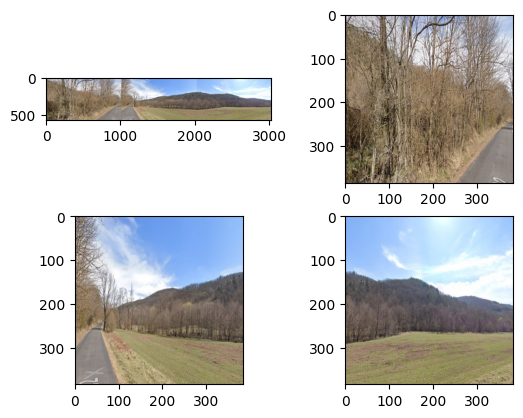

In [ ]:
# view the first image in original and reshaped to compare
plt.subplot(2, 2, 1)
plt.imshow(sample['image'][0].permute(1, 2, 0))
plt.subplot(2, 2, 2)
plt.imshow(new_dataset[0]['image'].permute(1, 2, 0))
plt.subplot(2, 2, 3)
plt.imshow(new_dataset[1]['image'].permute(1, 2, 0))
plt.subplot(2, 2, 4)
plt.imshow(new_dataset[2]['image'].permute(1, 2, 0))
plt.show()

In [ ]:
new_dataset[0]['image'].shape

torch.Size([3, 384, 384])

In [ ]:
input_size = 3 * 384 * 384

# Testing basic model
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_size, 256),
    nn.ReLU(),
    nn.Linear(256, 2)
)

# Test with one image
example_image = new_dataset[0]['image'].unsqueeze(0)
output = model(example_image.float())

print("Predicted Latitude and Longitude:", output)

Predicted Latitude and Longitude: tensor([[-45.9872,  33.6120]], grad_fn=<AddmmBackward0>)


In [ ]:
# Use mobilenet v3 as the model, without pretrained weights
model2 = torch.hub.load('pytorch/vision', 'mobilenet_v3_small', weights = 'IMAGENET1K_V1')
# replace the head to output 2 numbers for regression
model2.classifier[3] = nn.Linear(in_features=1024, out_features=2, bias=True)
model2

Downloading: "https://github.com/pytorch/vision/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 134MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [ ]:
# test on example image
example_image = new_dataset[0]['image'].unsqueeze(0)
output = model2(example_image.float())

print("Predicted Latitude and Longitude:", output)

Predicted Latitude and Longitude: tensor([[ 0.0168, -0.0195]], grad_fn=<AddmmBackward0>)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [ ]:
# Define optimizer and loss function
optimizer = optim.Adam(model2.parameters(), lr=0.001)
criterion = HaversineLoss()

# Create DataLoader
dataloader = DataLoader(new_dataset, batch_size=10, shuffle=True)

num_epochs = 3
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{3}"):
        optimizer.zero_grad()
        images = batch['image'].float()
        images = images.to(device)
        # Assuming 'lat' and 'lon' are the target latitude and longitude
        targets = torch.stack((torch.tensor(batch['latitude']), torch.tensor(batch['longitude'])), dim=1)
        targets = targets.to(device)

        # Forward pass
        outputs = model2(images)

        # Calculate the loss
        loss = criterion(outputs, targets)

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(dataloader)}")


Epoch 1/3:   0%|          | 0/150 [00:00<?, ?it/s]

<ipython-input-15-938024c57b5f>:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.stack((torch.tensor(batch['latitude']), torch.tensor(batch['longitude'])), dim=1)


Epoch 1/3, Loss: 5861.32193359375


Epoch 2/3:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/3, Loss: 5395.982975260416


Epoch 3/3:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 3/3, Loss: 5382.33354329427


In [ ]:
# save the model
torch.save(model2.state_dict(), 'model_scratch_cnn.pt')

In [ ]:
batch['image'].tolist()